# Red Neuronal Modelo Orientado a Objetos

In [1]:
import numpy as np
import matplotlib.pyplot as ply

## Importar Imagenes MNIST

In [2]:
import gzip
import os
from os.path import isfile, join
from contextlib import contextmanager
import zipfile

### Tener cuidado con el formato de windows
mnist_path = "C:\\Users\\PC\\OneDrive\\Documentos\\MNIST"

def getListFiles(mnist_path : str) -> list:
    return [
        join(mnist_path, file) 
        for file in os.listdir(mnist_path) 
        if isfile(join(mnist_path, file))
    ]


@contextmanager
def open_mnist_file(path: str):
    """
    Abre archivos MNIST en formato:
    - .gz
    - .zip
    - sin comprimir (.idx*-ubyte)
    Devuelve un stream binario.
    """
    if path.endswith(".gz"):
        f = gzip.open(path, "rb")
        try:
            yield f
        finally:
            f.close()

    elif path.endswith(".zip"):
        zf = zipfile.ZipFile(path)
        try:
            inner_name = zf.namelist()[0]
            with zf.open(inner_name) as f:
                yield f
        finally:
            zf.close()

    else:
        with open(path, "rb") as f:
            yield f


def _read_int32_be(f) -> int:
    """Lee un entero de 32 bits big-endian."""
    return int.from_bytes(f.read(4), byteorder="big")


def _read_images(f):
    """Lee un archivo idx3-ubyte (imágenes)."""
    _ = _read_int32_be(f)          # magic number
    num_images = _read_int32_be(f)
    rows = _read_int32_be(f)
    cols = _read_int32_be(f)

    data = f.read()
    images = np.frombuffer(data, dtype=np.uint8)
    return images.reshape(num_images, rows, cols)


def _read_labels(f):
    """Lee un archivo idx1-ubyte (labels)."""
    _ = _read_int32_be(f)  # magic number
    _ = _read_int32_be(f)  # número de labels
    return np.frombuffer(f.read(), dtype=np.uint8)


def getImages(files: list[str]):
    x_train = y_train = x_test = y_test = None

    for path in files:
        with open_mnist_file(path) as f:

            if "train-images" in path:
                x_train = _read_images(f)

            elif "train-labels" in path:
                y_train = _read_labels(f)

            elif "t10k-images" in path:
                x_test = _read_images(f)

            elif "t10k-labels" in path:
                y_test = _read_labels(f)

    return x_train, y_train, x_test, y_test

files = getListFiles(mnist_path)

In [3]:
x_train_num, y_train_num, x_test_num, y_test_num = getImages(files)

### Datos de entrenamiento
x_train = x_train_num[:50000].reshape(50000, -1).astype(np.float32)
y_train = y_train_num[:50000].reshape(50000, 1)

### Datos de validación (los ultimos 10k)
x_val = x_train_num[50000:].reshape(10000, -1).astype(np.float32)
y_val = y_train_num[50000:].reshape(10000, 1)

### Datos de prueba (origialmente ya son 10k, solo se pasaron a vector)
x_test = x_test_num.copy().reshape(10000, -1).astype(np.float32)
y_test = y_test_num.copy().reshape(10000, 1)

In [4]:
### Normalizar para tener una media de 0 y una desv de 1.
def normalise(x_mean, x_std, x_data):
    return (x_data-x_mean)/x_std

In [5]:
x_mean = x_train.mean()
x_std = x_train.std()

x_train = normalise(x_mean, x_std, x_train)
x_val = normalise(x_mean, x_std, x_val)
x_test = normalise(x_mean, x_std, x_test)

print(x_train.mean(), x_train.std())

-3.1638146e-07 0.99999934


## Funciones Adicionales

In [6]:
def create_minibatches(batch_size, x, y, shuffle = True):
    '''
    Dim x --> #muestras, 784
    Dim y --> #muestras, 1
    '''
    ### Validamos que empaqueten las dimensiones de X y el y (target).
    assert x.shape[0] == y.shape[0], 'Error en cantidad de muestras'
    total_data = x.shape[0]
    ### Randomizar
    if shuffle:
        idxs = np.arange(total_data)
        np.random.shuffle(idxs)
        x = x[idxs]
        y = y[idxs]
    ### Objeto iterable.
    return ((x[i:i+batch_size], y[i:i+batch_size]) for i in range(0, total_data, batch_size))

## Nuestra Clase Linear, ReLU y Sequential

In [26]:
class np_tensor(np.ndarray): pass

### Clase Linear

In [35]:
class Linear():
    def __init__(self, input_size, output_size):
        '''
        Init parameters utilizando Kaiming He
        '''
        self.W = (np.random.randn(output_size, input_size) / np.sqrt(input_size/2)).view(np_tensor)
        self.b = (np.zeros((output_size, 1))).view(np_tensor)
    def __call__(self, X): # esta el foward de la clase lineal
        Z = self.W @ X + self.b
        return Z
    def backward(self, X, Z):
        X.grad = self.W.T @ Z.grad
        self.W.grad = Z.grad @ X.T
        self.b.grad = np.sum(Z.grad, axis = 1, keepdims=True)    

### Clase ReLu

In [37]:
class ReLU():
    def __call__(self, Z):
        return np.maximum(0, Z)
    def backward(self, Z, A):
        Z.grad = A.grad.copy()
        Z.grad[Z <= 0] = 0

### Clase Sequential

In [38]:

class Sequential_layers():
    def __init__(self, layers):
        '''
        layers - lista que contiene objetos de tipo Linear, ReLU
        '''
        self.layers = layers
        self.x = None
        self.outputs = {}
    def __call__(self, X):
        self.x = X 
        self.outputs['l0'] = self.x
        for i, layer in enumerate(self.layers, 1):
            self.x = layer(self.x)
            self.outputs['l'+str(i)]=self.x
        return self.x
    def backward(self):
        for i in reversed(range(len(self.layers))):
            self.layers[i].backward(self.outputs['l'+str(i)], self.outputs['l'+str(i+1)])
    def update(self, learning_rate = 1e-3):
        for layer in self.layers:
            if isinstance(layer, ReLU): continue
            layer.W = layer.W - learning_rate * layer.W.grad
            layer.b = layer.b - learning_rate * layer.b.grad
    def predict(self, X):
        return np.argmax(self.__call__(X))
            

## Cost Function

In [39]:

def softmaxXEntropy(x, y):
    batch_size = x.shape[1]
    exp_scores = np.exp(x)
    probs = exp_scores / exp_scores.sum(axis = 0)
    preds = probs.copy()
    # Costo
    y_hat = probs[y.squeeze(), np.arange(batch_size)]
    cost = np.sum(-np.log(y_hat)) / batch_size
    # Calcular gradientes
    probs[y.squeeze(), np.arange(batch_size)] -= 1 #dl/dx
    x.grad = probs.copy()
    
    return preds, cost

## Loop de entrenamiento

In [40]:
def train(model, epochs, mb_size=128, learning_rate = 1e-3):
    for epoch in range(epochs):
        for i, (x, y) in enumerate(create_minibatches(mb_size, x_train, y_train)):
            scores = model(x.T.view(np_tensor))
            _, cost = softmaxXEntropy(scores, y)
            model.backward()
            model.update(learning_rate)
        print(f'costo: {cost}, accuracy: {accuracy(x_val, y_val, mb_size)}')

In [41]:

def accuracy(x, y, mb_size):
    correct = 0
    total = 0
    for i, (x, y) in enumerate(create_minibatches(mb_size, x, y)):
        pred = model(x.T.view(np_tensor))
        correct += np.sum(np.argmax(pred, axis=0) == y.squeeze())
        total += pred.shape[1]
    return correct/total

In [42]:
model = Sequential_layers([Linear(784, 200), ReLU(), Linear(200, 200), ReLU(), Linear(200, 10)])
mb_size = 512
learning_rate = 1e-4
epochs = 20

In [43]:
train(model, epochs, mb_size, learning_rate)

costo: 0.3021409528360587, accuracy: 0.9156
costo: 0.2343541040830527, accuracy: 0.9343
costo: 0.18169432711707056, accuracy: 0.9447
costo: 0.1588102554627055, accuracy: 0.9498
costo: 0.10764296739979244, accuracy: 0.9567
costo: 0.11744312996934225, accuracy: 0.9587
costo: 0.13350854650743774, accuracy: 0.9617
costo: 0.07095336360657652, accuracy: 0.9636
costo: 0.0878937677772779, accuracy: 0.9652
costo: 0.10805167624498721, accuracy: 0.9669
costo: 0.07944403966908029, accuracy: 0.9682
costo: 0.11752245479595828, accuracy: 0.9683
costo: 0.0762432009959416, accuracy: 0.9701
costo: 0.08514819732216347, accuracy: 0.9708
costo: 0.07721705700045133, accuracy: 0.971
costo: 0.06432405163087752, accuracy: 0.9714
costo: 0.07963691294671096, accuracy: 0.9724
costo: 0.07760842440479829, accuracy: 0.9735
costo: 0.04141618749223118, accuracy: 0.9741
costo: 0.07512159930326341, accuracy: 0.9742


In [44]:
print(accuracy(x_test, y_test, mb_size))

0.9705


In [50]:
import matplotlib.pyplot as plt
def plot_number(image):
    plt.figure(figsize=(5,5))
    plt.imshow(image.squeeze(), cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()

La imagen muestreada representa un: 5


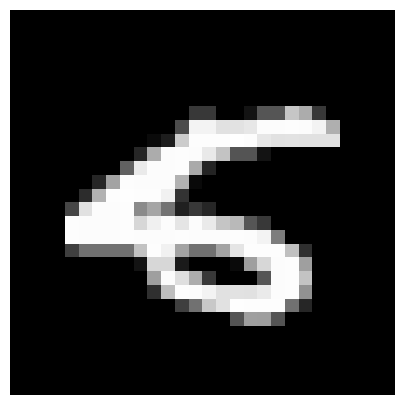

In [51]:

rnd_idx = np.random.randint(len(y_test))
print(f'La imagen muestreada representa un: {y_test[rnd_idx, 0]}')
plot_number(x_test_num[rnd_idx])

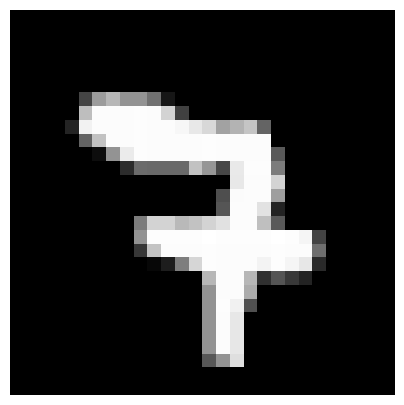

el valor predicho es: 7, el valor real es:7


In [52]:
idx = np.random.randint(len(y_test))
plot_number(x_test_num[idx])
pred = model.predict(x_test[idx].reshape(-1, 1))
print(f'el valor predicho es: {pred}, el valor real es:{y_test[idx][0]}')